# What is an AI agent?

The word "agent" is overloaded. In this notebook we mean specifically: **an LLM in a loop that can call tools.** That's the entire idea. Everything sophisticated downstream (planning, memory, multi-agent orchestration) is variations on this loop.

The loop, in pseudo-code:

```
while not done:
    response = llm(messages, tools)
    if response.tool_calls:
        for call in response.tool_calls:
            result = run_tool(call.name, call.arguments)
            messages.append(tool_result)
    else:
        done = True
return response.text
```

That's it. Six lines. We'll build it from scratch, then look at the production-ish version in `ai_playground.agents`.

**Why this pattern works.** An LLM by itself is a fixed-context text predictor — useful, but blind to current state (it doesn't know what files exist, what the weather is, what your DB has). Tools give it eyes and hands. The loop is what lets it *act* on intermediate results: read a file, decide what to do next, read another file, write an answer.

This pattern is called **ReAct** (Reasoning + Acting). [Paper: Yao et al., 2022](https://arxiv.org/abs/2210.03629).

See also: [docs/PAPERS.md § Agents](../../docs/PAPERS.md) · [Anthropic: Building effective agents](https://www.anthropic.com/research/building-effective-agents)

::: {.callout-tip title="⏱️ Session S6.1" appearance="simple"}
One session (epilogue): read and run, then trace one ReAct loop iteration on paper.
Cards, prerequisites, and done-when tests: the [Session Guide](../../docs/SESSIONS.md).
:::

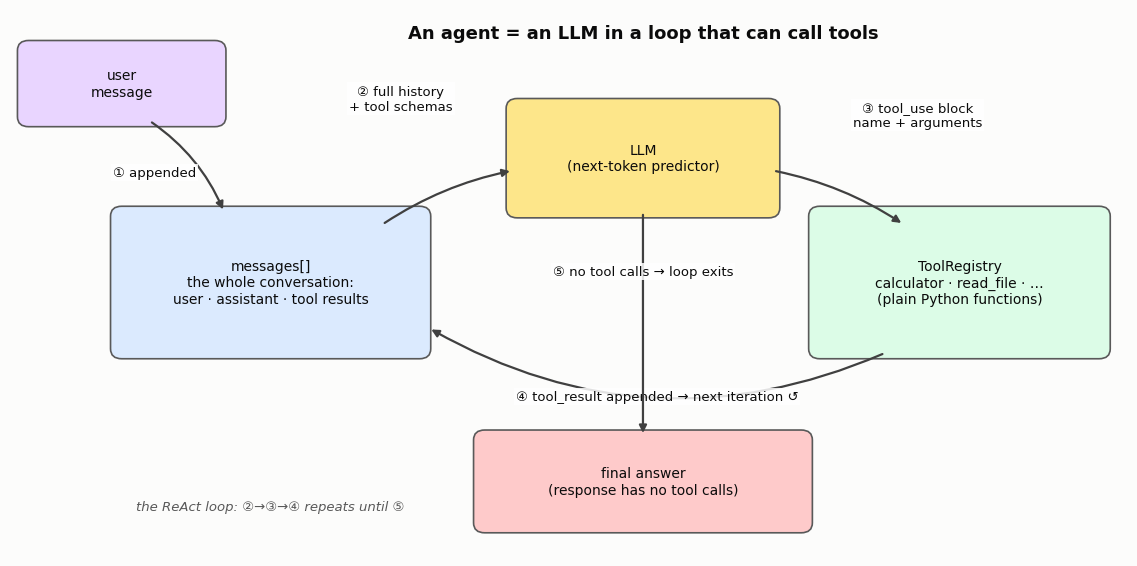

In [1]:
#| code-fold: true
#| code-summary: "Draw: the agent loop"
import sys
sys.path.insert(0, '../../src')
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

from ai_playground.plotting import apply_plot_style
apply_plot_style()

fig, ax = plt.subplots(figsize=(11.5, 5.8))
ax.set_xlim(0, 12); ax.set_ylim(0, 6.6); ax.axis('off')

def draw_box(x, y, w, h, text, fc, fontsize=10):
    ax.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                boxstyle='round,pad=0.12', fc=fc, ec='0.35', lw=1.2))
    ax.text(x, y, text, ha='center', va='center', fontsize=fontsize)

def draw_arrow(p, q, label, curve=0.0, label_xy=None):
    ax.annotate('', xy=q, xytext=p,
                arrowprops=dict(arrowstyle='-|>', lw=1.6, color='0.25',
                                connectionstyle=f'arc3,rad={curve}'))
    if label_xy is None:
        label_xy = ((p[0] + q[0]) / 2, (p[1] + q[1]) / 2 + 0.18)
    ax.text(*label_xy, label, ha='center', va='bottom', fontsize=9.5,
            bbox=dict(fc='white', ec='none', alpha=0.85, pad=1.5))

draw_box(1.2, 5.7, 2.0, 0.8, 'user\nmessage', '#e9d5ff')
draw_box(2.8, 3.3, 3.2, 1.6, 'messages[]\nthe whole conversation:\nuser · assistant · tool results', '#dbeafe')
draw_box(6.8, 4.8, 2.7, 1.2, 'LLM\n(next-token predictor)', '#fde68a')
draw_box(10.2, 3.3, 3.0, 1.6, 'ToolRegistry\ncalculator · read_file · …\n(plain Python functions)', '#dcfce7')
draw_box(6.8, 0.9, 3.4, 1.0, 'final answer\n(response has no tool calls)', '#fecaca')

draw_arrow((1.5, 5.25), (2.3, 4.15), '\u2460 appended', curve=-0.15, label_xy=(1.55, 4.55))
draw_arrow((4.0, 4.0), (5.4, 4.65), '\u2461 full history\n+ tool schemas', curve=-0.1,
           label_xy=(4.2, 5.35))
draw_arrow((8.2, 4.65), (9.6, 4.0), '\u2462 tool_use block\nname + arguments', curve=-0.1,
           label_xy=(9.75, 5.15))
draw_arrow((9.4, 2.45), (4.5, 2.75), '\u2463 tool_result appended \u2192 next iteration \u21ba',
           curve=-0.25, label_xy=(6.95, 1.85))
draw_arrow((6.8, 4.15), (6.8, 1.45), '\u2464 no tool calls \u2192 loop exits',
           label_xy=(6.8, 3.35))

ax.text(6.8, 6.25, 'An agent = an LLM in a loop that can call tools',
        ha='center', fontsize=13, fontweight='bold')
ax.text(2.8, 0.55, 'the ReAct loop: \u2461\u2192\u2462\u2192\u2463 repeats until \u2464',
        ha='center', fontsize=9.5, style='italic', color='0.35')
plt.tight_layout()
plt.show()

## 1. The simplest possible agent

We'll skip the LLM API at first and use a **scripted backend** — a fake model that returns pre-baked responses. This lets us focus on the loop itself, with no network and no surprises.

The "model" will pretend to answer "what is 17 * 23?" by asking us to call a calculator tool, then reading the result.

In [2]:
import sys
sys.path.insert(0, '../../src')

from ai_playground.agents import Tool, ToolRegistry
from ai_playground.agents.llm import LLMResponse, ToolCall

# A tiny scripted 'LLM' — returns responses in order.
class ScriptedLLM:
    def __init__(self, responses):
        self.responses = list(responses)
    def complete(self, messages, tools=None, system=None, max_tokens=1024):
        print(f'  [scripted LLM called with {len(messages)} message(s)]')
        return self.responses.pop(0)

# A real tool — actually computes things.
calc = Tool(
    name='calculator',
    description='evaluate a math expression',
    input_schema={'type': 'object', 'properties': {'expr': {'type': 'string'}}, 'required': ['expr']},
    func=lambda expr: str(eval(expr, {'__builtins__': {}}, {})),
)

registry = ToolRegistry([calc])

# Pretend the model decides to call the tool, then reads the result.
script = [
    LLMResponse(
        text="Let me compute that.",
        tool_calls=[ToolCall(id='c1', name='calculator', arguments={'expr': '17 * 23'})],
        stop_reason='tool_use',
    ),
    LLMResponse(text="17 * 23 = 391.", stop_reason='end_turn'),
]
llm = ScriptedLLM(script)

## 2. Now the loop itself

This is the whole agent in ~15 lines. Read it carefully — every other agent framework you'll ever see is essentially this with more bells on.

In [3]:
def minimal_agent(llm, tools, user_message, max_iter=5):
    messages = [{'role': 'user', 'content': user_message}]
    for i in range(max_iter):
        print(f'\n--- iteration {i} ---')
        response = llm.complete(messages, tools=tools.list())
        # Record the assistant's turn so the model sees its own tool requests
        messages.append({'role': 'assistant', 'content': [
            *([{'type': 'text', 'text': response.text}] if response.text else []),
            *[{'type': 'tool_use', 'id': c.id, 'name': c.name, 'input': c.arguments} for c in response.tool_calls],
        ]})
        if not response.tool_calls:
            print(f'  model says: {response.text}')
            return response.text
        # Dispatch each tool and feed results back
        results = []
        for call in response.tool_calls:
            print(f'  model wants to call {call.name}({call.arguments})')
            r = tools.dispatch(call.name, call.arguments, call.id)
            print(f'  -> tool returned: {r.content!r}')
            results.append(r.to_anthropic_block())
        messages.append({'role': 'user', 'content': results})
    return '[hit max iterations]'

answer = minimal_agent(llm, registry, 'what is 17 * 23?')
print(f'\nFINAL: {answer}')


--- iteration 0 ---
  [scripted LLM called with 1 message(s)]
  model wants to call calculator({'expr': '17 * 23'})
  -> tool returned: '391'

--- iteration 1 ---
  [scripted LLM called with 3 message(s)]
  model says: 17 * 23 = 391.

FINAL: 17 * 23 = 391.


## 3. The ReAct cycle in slow motion

Notice what just happened:

1. We sent the user's question to the "model".
2. Instead of answering, the model **acted**: it asked us to invoke `calculator` with `expr='17 * 23'`.
3. We ran the tool. Its output (`'391'`) went back to the model as a `tool_result` message.
4. Now the model had the missing piece, and on the next turn it **reasoned**: combined the original question with the tool output and produced a natural-language answer.

This Reason-Act-Reason-Act pattern is what makes an agent useful for anything beyond a single LLM call. The model uses tools to fill in what it doesn't know; the tool outputs constrain its next reasoning step.

Key insight: **"tool calling" isn't a special model capability.** The model just emits structured text (`tool_use` blocks), and a wrapper parses those out and dispatches. Anthropic's API hides the parsing inside the SDK; OpenAI's function calling does the same. Underneath, it's pattern-matching on tokens.

The same run, drawn as a sequence diagram — time flows downward; note that the
model never touches the tool directly, everything routes through the loop:

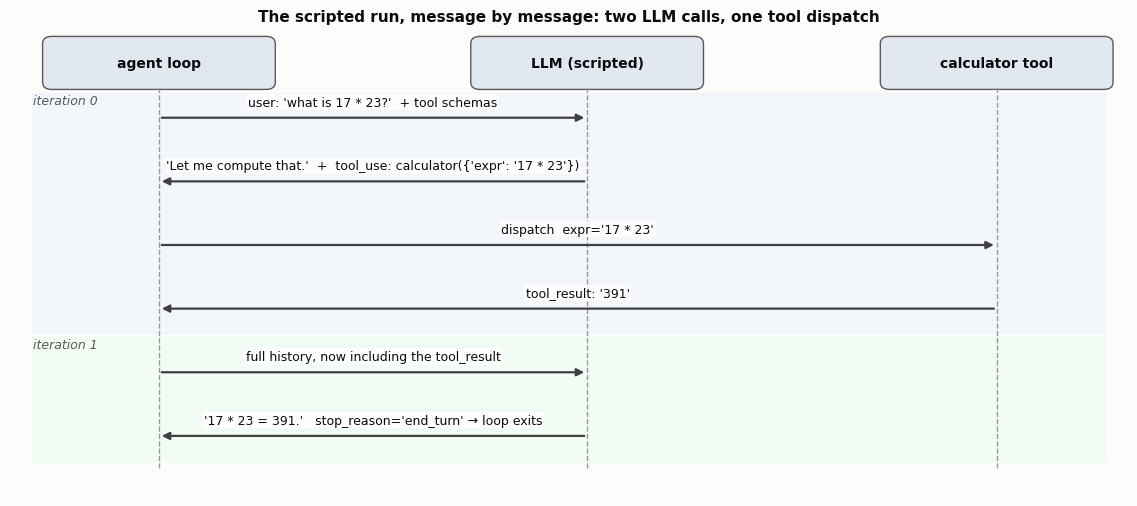

In [4]:
#| code-fold: true
#| code-summary: "Draw: the run above, as a sequence diagram"
fig, ax = plt.subplots(figsize=(11.5, 5.2))
ax.set_xlim(0, 12); ax.set_ylim(0, 6.6); ax.axis('off')

lanes = {'agent loop': 1.6, 'LLM (scripted)': 6.2, 'calculator tool': 10.6}
for name, x in lanes.items():
    ax.add_patch(FancyBboxPatch((x - 1.15, 5.85), 2.3, 0.55, boxstyle='round,pad=0.1',
                                fc='#e2e8f0', ec='0.35'))
    ax.text(x, 6.12, name, ha='center', va='center', fontsize=10, fontweight='bold')
    ax.vlines(x, 0.4, 5.8, color='0.6', ls='--', lw=1)

# (y, from, to, label) in time order, top to bottom — mirrors the printed trace above
events = [
    (5.35, 'agent loop', 'LLM (scripted)', "user: 'what is 17 * 23?'  + tool schemas"),
    (4.45, 'LLM (scripted)', 'agent loop',
     "'Let me compute that.'  +  tool_use: calculator({'expr': '17 * 23'})"),
    (3.55, 'agent loop', 'calculator tool', "dispatch  expr='17 * 23'"),
    (2.65, 'calculator tool', 'agent loop', "tool_result: '391'"),
    (1.75, 'agent loop', 'LLM (scripted)', 'full history, now including the tool_result'),
    (0.85, 'LLM (scripted)', 'agent loop', "'17 * 23 = 391.'   stop_reason='end_turn' \u2192 loop exits"),
]
for y, src, dst, label in events:
    x0, x1 = lanes[src], lanes[dst]
    ax.annotate('', xy=(x1, y), xytext=(x0, y),
                arrowprops=dict(arrowstyle='-|>', lw=1.6, color='0.25'))
    ax.text((x0 + x1) / 2, y + 0.13, label, ha='center', va='bottom', fontsize=9,
            bbox=dict(fc='white', ec='none', alpha=0.85, pad=1.2))

# Iteration bands: one loop pass = one LLM call plus whatever tools it asked for
ax.axhspan(2.3, 5.7, xmin=0.02, xmax=0.98, color='#dbeafe', alpha=0.25, zorder=0)
ax.axhspan(0.5, 2.25, xmin=0.02, xmax=0.98, color='#dcfce7', alpha=0.3, zorder=0)
ax.text(0.25, 5.55, 'iteration 0', fontsize=9, style='italic', color='0.35')
ax.text(0.25, 2.1, 'iteration 1', fontsize=9, style='italic', color='0.35')
ax.set_title('The scripted run, message by message: two LLM calls, one tool dispatch',
             fontsize=11)
plt.tight_layout()
plt.show()

## 4. Same thing, with the real Agent class

The minimal loop above is essentially `ai_playground.agents.Agent.run()` with more error handling. Same behavior:

In [5]:
from ai_playground.agents import Agent

# Reset the scripted LLM (we consumed its responses above)
llm = ScriptedLLM([
    LLMResponse(
        text="Let me compute that.",
        tool_calls=[ToolCall(id='c1', name='calculator', arguments={'expr': '17 * 23'})],
        stop_reason='tool_use',
    ),
    LLMResponse(text="17 * 23 = 391.", stop_reason='end_turn'),
])

agent = Agent(llm=llm, tools=ToolRegistry([calc]))
result = agent.run('what is 17 * 23?')
print(f'final text: {result.final_text}')
print(f'stop reason: {result.stop_reason}')
print(f'steps taken: {len(result.steps)}')
for i, step in enumerate(result.steps):
    print(f'  step {i}: text={step.response.text!r}, tool_calls={[c.name for c in step.response.tool_calls]}, results={[r.content for r in step.tool_results]}')

  [scripted LLM called with 1 message(s)]
  [scripted LLM called with 3 message(s)]
final text: 17 * 23 = 391.
stop reason: end_turn
steps taken: 2
  step 0: text='Let me compute that.', tool_calls=['calculator'], results=['391']
  step 1: text='17 * 23 = 391.', tool_calls=[], results=[]


## 5. Now with a real LLM (optional — needs an API key)

Swap `ScriptedLLM` for `ClaudeBackend`. Set `ANTHROPIC_API_KEY` in your environment first. Install the agents extra: `uv sync --extra agents`.

The loop doesn't change. That's the point of the backend abstraction.

In [6]:
# Uncomment to run with a real model:
# from ai_playground.agents import ClaudeBackend, builtin_tools
# 
# agent = Agent(
#     llm=ClaudeBackend(),
#     tools=ToolRegistry(builtin_tools(include_shell=False)),
#     system='You are a careful assistant. Use tools when needed.',
# )
# result = agent.run('Read /etc/hostname and tell me what host I am on.')
# print(result.final_text)
# for step in result.steps:
#     print(f' - {[c.name for c in step.response.tool_calls]} -> {[r.content[:60] for r in step.tool_results]}')

## Key takeaways

- **An agent is a loop.** Model emits text or tool calls; tool results feed back into the next model call; repeat until the model emits no more tool calls.
- **Tool calling is text.** The model emits a structured block; a parser dispatches; results come back as another message. There's no magic.
- **The backend abstraction matters.** Same loop, swap Claude for a local transformer for a different provider — the surface area is small on purpose.
- **Termination matters.** Always cap iterations. Models will happily loop forever.

### Next

- `01_tool_use.ipynb` — designing useful tools, JSON schemas, the security trade-offs of giving a model shell access
- `02_memory.ipynb` — short-term (conversation) and long-term (vector store) memory
- (later) planning, multi-agent orchestration